# SI 385 Group Project Analysis Notebook

### Analysis of NFL Stadium Attendance

###### Matthew Urbanczyk, Emily Adamo, Sam Gibson

#### Answering Research Questions 1 and 3

## Reading in and Cleaning Data

In [1]:
# import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statistics import stdev
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
nfl_attendance_stats = pd.read_csv('attendance.csv')
nfl_games_stats = pd.read_csv('games.csv')
nfl_standings_stats = pd.read_csv('standings.csv')

In [3]:
nfl_attendance_stats.describe()

,year,total,home,away,week,weekly_attendance
count,10846.000000,1.084600e+04,10846.000000,10846.000000,10846.000000,10208.000000
mean,2009.528213,1.080910e+06,540455.012539,540455.012539,9.000000,67556.876567
std,5.753415,7.287697e+04,66774.652550,25509.325673,4.899205,9022.015325
min,2000.000000,7.606440e+05,202687.000000,450295.000000,1.000000,23127.000000
25%,2005.000000,1.040509e+06,504360.000000,524974.000000,5.000000,63245.500000
50%,2010.000000,1.081090e+06,543185.000000,541757.000000,9.000000,68334.000000
75%,2015.000000,1.123230e+06,578342.000000,557741.000000,13.000000,72544.750000
max,2019.000000,1.322087e+06,741775.000000,601655.000000,17.000000,105121.000000


In [4]:
nfl_attendance_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10846 entries, 0 to 10845
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   team               10846 non-null  object 
 1   team_name          10846 non-null  object 
 2   year               10846 non-null  int64  
 3   total              10846 non-null  int64  
 4   home               10846 non-null  int64  
 5   away               10846 non-null  int64  
 6   week               10846 non-null  int64  
 7   weekly_attendance  10208 non-null  float64
dtypes: float64(1), int64(5), object(2)
memory usage: 678.0+ KB


In [5]:
nfl_attendance_stats

,team,team_name,year,total,home,away,week,weekly_attendance
0,Arizona,Cardinals,2000,893926,387475,506451,1,77434.0
1,Arizona,Cardinals,2000,893926,387475,506451,2,66009.0
2,Arizona,Cardinals,2000,893926,387475,506451,3,NaN
3,Arizona,Cardinals,2000,893926,387475,506451,4,71801.0
4,Arizona,Cardinals,2000,893926,387475,506451,5,66985.0
...,...,...,...,...,...,...,...,...
10841,Washington,Redskins,2019,1101466,523906,577560,13,71504.0
10842,Washington,Redskins,2019,1101466,523906,577560,14,77296.0
10843,Washington,Redskins,2019,1101466,523906,577560,15,63246.0
10844,Washington,Redskins,2019,1101466,523906,577560,16,66083.0


In [6]:
nfl_standings_stats

,team,team_name,year,wins,loss,points_for,points_against,points_differential,margin_of_victory,strength_of_schedule,simple_rating,offensive_ranking,defensive_ranking,playoffs,sb_winner
0,Miami,Dolphins,2000,11,5,323,226,97,6.1,1.0,7.1,0.0,7.1,Playoffs,No Superbowl
1,Indianapolis,Colts,2000,10,6,429,326,103,6.4,1.5,7.9,7.1,0.8,Playoffs,No Superbowl
2,New York,Jets,2000,9,7,321,321,0,0.0,3.5,3.5,1.4,2.2,No Playoffs,No Superbowl
3,Buffalo,Bills,2000,8,8,315,350,-35,-2.2,2.2,0.0,0.5,-0.5,No Playoffs,No Superbowl
4,New England,Patriots,2000,5,11,276,338,-62,-3.9,1.4,-2.5,-2.7,0.2,No Playoffs,No Superbowl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
633,Carolina,Panthers,2019,5,11,340,470,-130,-8.1,1.1,-7.0,-1.9,-5.1,No Playoffs,No Superbowl
634,San Francisco,49ers,2019,13,3,479,310,169,10.6,0.4,11.0,6.7,4.3,Playoffs,No Superbowl
635,Seattle,Seahawks,2019,11,5,405,398,7,0.4,2.3,2.7,2.9,-0.2,Playoffs,No Superbowl
636,Los Angeles,Rams,2019,9,7,394,364,30,1.9,2.0,3.9,2.2,1.7,No Playoffs,No Superbowl


## Research Question 1

###### How has average team performance (points scored) changed over the years (2000–2019)?

In [7]:
def get_avg_points_per_game(row):
    games_total = row['wins'] + row['loss']
    points_total = row['points_for']
    return points_total / games_total

In [8]:
nfl_standings_stats['avg_points_per_game'] = nfl_standings_stats.apply(get_avg_points_per_game, axis=1)

In [9]:
nfl_standings_stats['year'] = nfl_standings_stats['year'].astype('str')

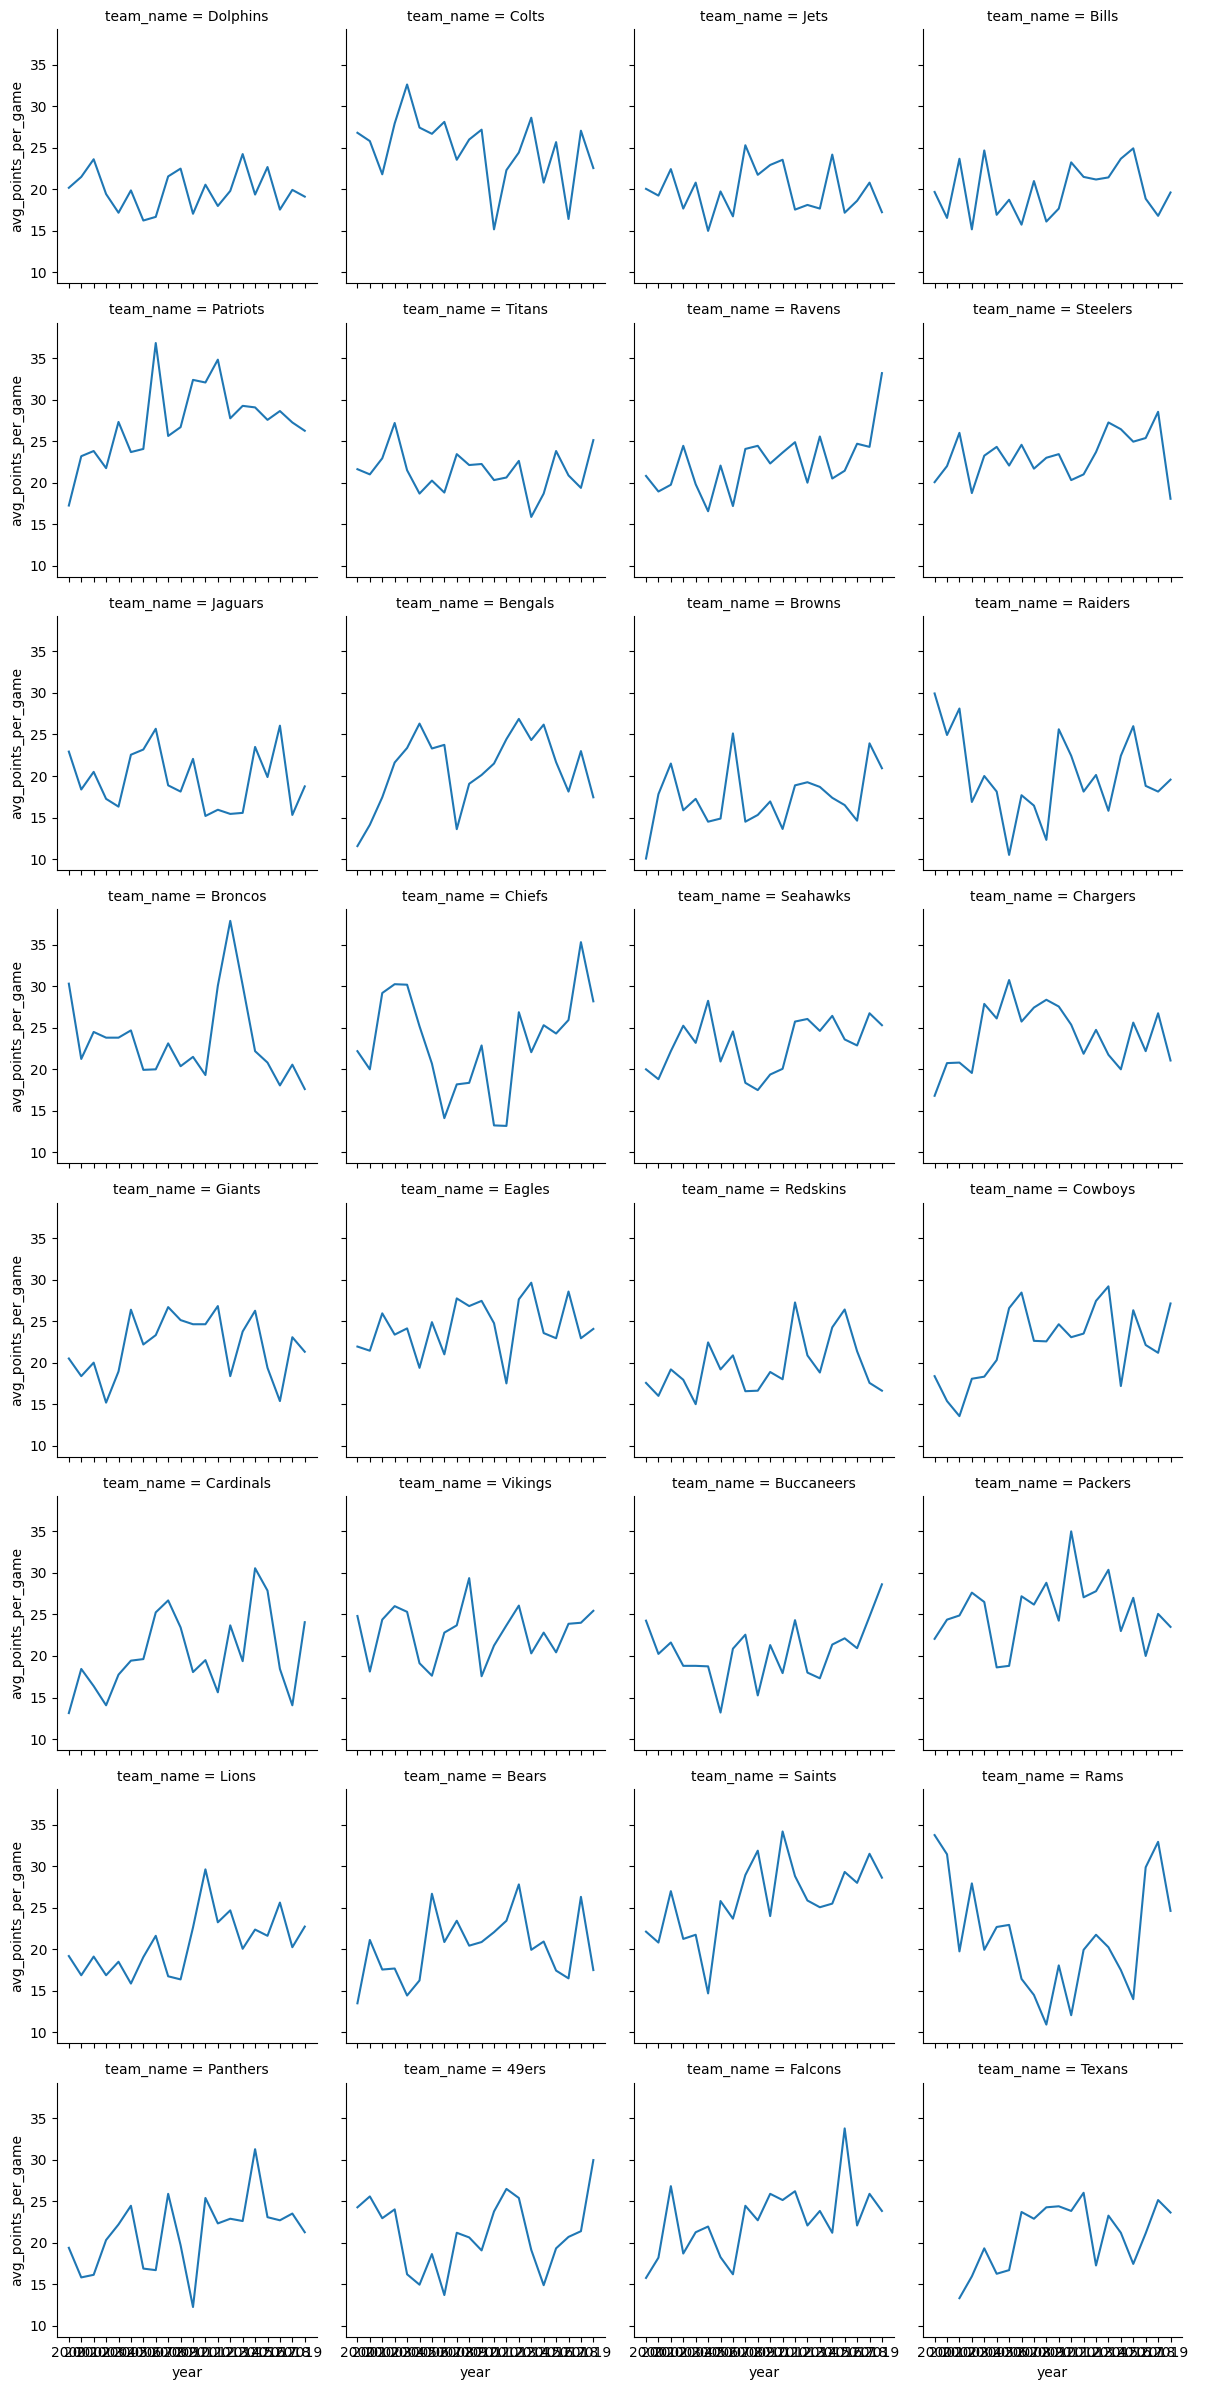

In [10]:
sns.FacetGrid(nfl_standings_stats,
              col='team_name',
              col_wrap=4).map(sns.lineplot,
                              'year',
                              'avg_points_per_game').add_legend()
plt.show()

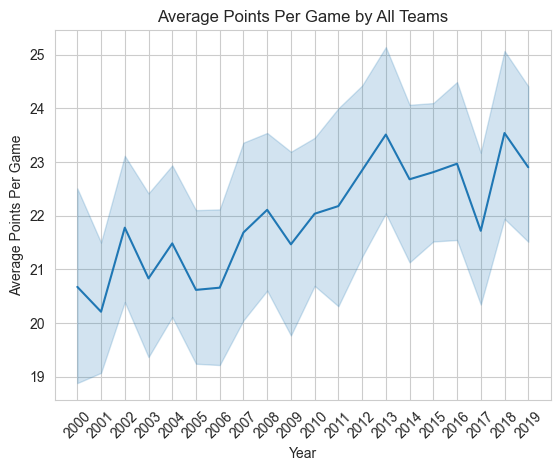

In [11]:
sns.set_style('whitegrid')
sns.lineplot(data=nfl_standings_stats, x='year', y='avg_points_per_game')
plt.xlabel('Year')
plt.ylabel('Average Points Per Game')
plt.title('Average Points Per Game by All Teams')
plt.xticks(rotation=45)
plt.show()

In [12]:
season_2000 = nfl_standings_stats[nfl_standings_stats['year'] == '2000']
season_2019 = nfl_standings_stats[nfl_standings_stats['year'] == '2019']
percent_change = ((season_2019['avg_points_per_game'].sum() - season_2000['avg_points_per_game'].sum()) / season_2000['avg_points_per_game'].sum()) * 100
print(f'Percent change in average points per game from 2000 to 2019: {percent_change:.2f}%')

Percent change in average points per game from 2000 to 2019: 14.36%


In [13]:
print(season_2019['avg_points_per_game'].mean())
print(season_2000['avg_points_per_game'].mean())

22.90390625
20.673387096774192


In [14]:
league_std_dev = stdev(nfl_standings_stats['avg_points_per_game'])
print(f'Standard deviation of average points per game across the league: {league_std_dev:.2f}')

Standard deviation of average points per game across the league: 4.49


In [15]:
nfl_standings_stats.groupby('team_name')['avg_points_per_game'].apply(np.mean).sort_values(ascending=False)

team_name
Patriots      27.259375
Saints        25.940625
Packers       25.405833
Colts         24.856250
Eagles        24.280417
Chargers      24.059375
Broncos       23.496875
Chiefs        23.284375
Steelers      23.236042
Seahawks      22.995625
Vikings       22.834583
Falcons       22.696250
Ravens        22.428125
Cowboys       22.296875
Giants        22.012500
Rams          21.565417
Titans        21.356250
Panthers      21.226875
49ers         21.098333
Bengals       20.892500
Texans        20.861111
Lions         20.655417
Buccaneers    20.553125
Cardinals     20.271667
Bears         20.240625
Raiders       20.100000
Bills         19.868750
Dolphins      19.859375
Jets          19.837500
Jaguars       19.575000
Redskins      19.570000
Browns        17.377917
Name: avg_points_per_game, dtype: float64

In [16]:
# Calculate standard deviation of average points per game for each team sorted highest to lowest
team_std_dev = nfl_standings_stats.groupby('team_name')['avg_points_per_game'].apply(stdev).sort_values(ascending=False)
print(team_std_dev)

team_name
Rams          6.779547
Chiefs        6.006420
Broncos       5.056078
Raiders       5.001702
Cardinals     4.872389
Patriots      4.547776
Saints        4.543262
Cowboys       4.481361
Bengals       4.384426
Panthers      4.286243
49ers         4.276497
Falcons       4.201353
Colts         4.138092
Bears         3.972369
Packers       3.915821
Texans        3.833000
Chargers      3.655974
Ravens        3.655063
Giants        3.637546
Browns        3.596901
Jaguars       3.553376
Lions         3.542076
Buccaneers    3.519639
Redskins      3.379355
Vikings       3.177501
Seahawks      3.171790
Eagles        3.154710
Bills         3.133009
Jets          2.815196
Steelers      2.796257
Titans        2.534556
Dolphins      2.321141
Name: avg_points_per_game, dtype: float64


## Research Question 3

###### Which teams are the most dominant offensively based on average yards gained per game?

In [17]:
# write function to identify losing team
def get_losing_team(row):
    if row['winner'] == row['home_team']:
        return row['away_team']
    else:
        return row['home_team']

In [18]:
nfl_games_stats['loser'] = nfl_games_stats.apply(get_losing_team, axis=1)

In [19]:
nfl_games_stats

,year,week,home_team,away_team,winner,tie,day,date,time,pts_win,pts_loss,yds_win,turnovers_win,yds_loss,turnovers_loss,home_team_name,home_team_city,away_team_name,away_team_city,loser
0,2000,1,Minnesota Vikings,Chicago Bears,Minnesota Vikings,NaN,Sun,September 3,1:00PM,30,27,374,1,425,1,Vikings,Minnesota,Bears,Chicago,Chicago Bears
1,2000,1,Kansas City Chiefs,Indianapolis Colts,Indianapolis Colts,NaN,Sun,September 3,1:00PM,27,14,386,2,280,1,Chiefs,Kansas City,Colts,Indianapolis,Kansas City Chiefs
2,2000,1,Washington Redskins,Carolina Panthers,Washington Redskins,NaN,Sun,September 3,1:01PM,20,17,396,0,236,1,Redskins,Washington,Panthers,Carolina,Carolina Panthers
3,2000,1,Atlanta Falcons,San Francisco 49ers,Atlanta Falcons,NaN,Sun,September 3,1:02PM,36,28,359,1,339,1,Falcons,Atlanta,49ers,San Francisco,San Francisco 49ers
4,2000,1,Pittsburgh Steelers,Baltimore Ravens,Baltimore Ravens,NaN,Sun,September 3,1:02PM,16,0,336,0,223,1,Steelers,Pittsburgh,Ravens,Baltimore,Pittsburgh Steelers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5319,2019,Division,Kansas City Chiefs,Houston Texans,Kansas City Chiefs,NaN,Sun,January 12,3:05PM,51,31,434,1,442,1,Chiefs,Kansas City,Texans,Houston,Houston Texans
5320,2019,Division,Green Bay Packers,Seattle Seahawks,Green Bay Packers,NaN,Sun,January 12,6:40PM,28,23,344,0,375,0,Packers,Green Bay,Seahawks,Seattle,Seattle Seahawks
5321,2019,ConfChamp,Kansas City Chiefs,Tennessee Titans,Kansas City Chiefs,NaN,Sun,January 19,3:05PM,35,24,404,0,295,0,Chiefs,Kansas City,Titans,Tennessee,Tennessee Titans
5322,2019,ConfChamp,San Francisco 49ers,Green Bay Packers,San Francisco 49ers,NaN,Sun,January 19,6:40PM,37,20,354,0,358,3,49ers,San Francisco,Packers,Green Bay,Green Bay Packers


In [20]:
# Initialize new dataframe
columns = ['year', 'team', 'total_wins','total_losses', 'avg_yards_win', 'avg_yards_lose']
avg_yards_by_team_per_year = pd.DataFrame(columns=columns)
avg_yards_by_team_per_year

,year,team,total_wins,total_losses,avg_yards_win,avg_yards_lose


In [21]:
# Calculate average yards for each team
for year in nfl_games_stats['year'].unique():
    for team in nfl_games_stats['home_team'].unique():
        team_wins = nfl_games_stats[(nfl_games_stats['year'] == year) & (nfl_games_stats['winner'] == team)]
        team_losses = nfl_games_stats[(nfl_games_stats['year'] == year) & (nfl_games_stats['loser'] == team)]
        avg_yards_win = team_wins['yds_win'].mean()
        avg_yards_lose = team_losses['yds_loss'].mean()
        total_wins = len(team_wins)
        total_losses = len(team_losses)

        new_row = {
            'year': year,
            'team': team,
            'total_wins': total_wins,
            'total_losses': total_losses,
            'avg_yards_win': avg_yards_win,
            'avg_yards_lose': avg_yards_lose,
        }

        avg_yards_by_team_per_year = pd.concat([avg_yards_by_team_per_year, pd.DataFrame([new_row])], ignore_index=True)

C:\Users\matth\AppData\Local\Temp\ipykernel_3996\2323468112.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  avg_yards_by_team_per_year = pd.concat([avg_yards_by_team_per_year, pd.DataFrame([new_row])], ignore_index=True)


In [22]:
def get_total_avg_yards(row):
    total_games = row['total_wins'] + row['total_losses']
    total_yards = (row['avg_yards_win'] * row['total_wins']) + (row['avg_yards_lose'] * row['total_losses'])
    return total_yards / total_games

In [23]:
# drop rows with NaN values because some teams may not have played/existed in certain years
avg_yards_by_team_per_year.dropna(inplace=True)

In [24]:
avg_yards_by_team_per_year['total_avg_yards'] = avg_yards_by_team_per_year.apply(get_total_avg_yards, axis=1)
avg_yards_by_team_per_year

,year,team,total_wins,total_losses,avg_yards_win,avg_yards_lose,total_avg_yards
0,2000,Minnesota Vikings,12,6,386.166667,311.666667,361.333333
1,2000,Kansas City Chiefs,7,9,396.571429,315.333333,350.875000
2,2000,Washington Redskins,8,8,360.875000,313.625000,337.250000
3,2000,Atlanta Falcons,4,12,297.500000,233.666667,249.625000
4,2000,Pittsburgh Steelers,9,7,309.777778,282.571429,297.875000
...,...,...,...,...,...,...,...
675,2019,Carolina Panthers,5,11,358.600000,334.181818,341.812500
676,2019,Chicago Bears,8,8,317.375000,276.250000,296.812500
677,2019,Houston Texans,11,7,376.000000,351.142857,366.333333
678,2019,Los Angeles Rams,9,7,403.888889,337.571429,374.875000


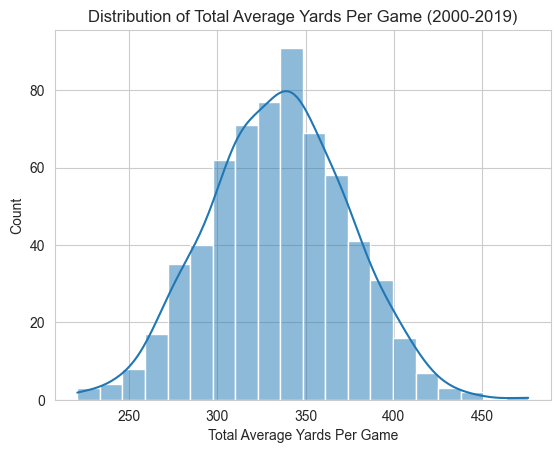

In [25]:
# Histogram of total average yards per game (2000-2019)
sns.histplot(data=avg_yards_by_team_per_year, x='total_avg_yards', bins=20, kde=True)
plt.xlabel('Total Average Yards Per Game')
plt.title('Distribution of Total Average Yards Per Game (2000-2019)')
plt.show()

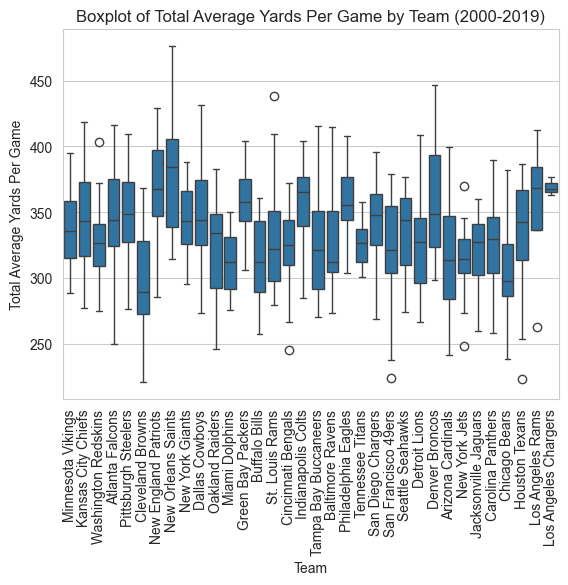

In [26]:
# Boxplot of total average yards per game by team
sns.boxplot(data=avg_yards_by_team_per_year, x='team', y='total_avg_yards')
plt.xlabel('Team')
plt.ylabel('Total Average Yards Per Game')
plt.title('Boxplot of Total Average Yards Per Game by Team (2000-2019)')
plt.xticks(rotation=90)
plt.show()

In [27]:
# Getting the teams with the highest total average yards per game
avg_yards_by_team_per_year.groupby('team')['total_avg_yards'].mean().sort_values(ascending=False)

team
New Orleans Saints      378.577734
Los Angeles Chargers    369.131944
New England Patriots    366.230776
Green Bay Packers       358.615404
Indianapolis Colts      357.026736
Philadelphia Eagles     356.292272
Denver Broncos          355.499460
Los Angeles Rams        352.850377
Pittsburgh Steelers     349.055648
Kansas City Chiefs      346.771794
San Diego Chargers      345.681236
Dallas Cowboys          345.224734
Atlanta Falcons         343.541866
New York Giants         343.391931
Minnesota Vikings       340.956658
Seattle Seahawks        336.659981
St. Louis Rams          331.964042
Houston Texans          331.442357
Tampa Bay Buccaneers    327.169669
Washington Redskins     327.056087
Detroit Lions           326.346943
Tennessee Titans        326.150174
Baltimore Ravens        325.843663
Carolina Panthers       324.692599
Oakland Raiders         324.045517
Cincinnati Bengals      322.895588
San Francisco 49ers     322.547849
Jacksonville Jaguars    322.248519
Arizona Cardina

In [28]:
# Getting teams by greatest number of wins
avg_yards_by_team_per_year.groupby('team')['total_wins'].sum().sort_values(ascending=False)

team
New England Patriots    267
Pittsburgh Steelers     222
Indianapolis Colts      210
Green Bay Packers       210
Philadelphia Eagles     205
Baltimore Ravens        205
Seattle Seahawks        197
New Orleans Saints      192
Denver Broncos          189
Minnesota Vikings       172
Kansas City Chiefs      171
Dallas Cowboys          171
Atlanta Falcons         170
New York Giants         168
Tennessee Titans        165
Carolina Panthers       165
Chicago Bears           160
San Francisco 49ers     157
New York Jets           154
Miami Dolphins          150
Cincinnati Bengals      146
Arizona Cardinals       142
Tampa Bay Buccaneers    141
San Diego Chargers      140
Buffalo Bills           137
Houston Texans          135
Washington Redskins     134
Jacksonville Jaguars    130
Oakland Raiders         129
Detroit Lions           115
St. Louis Rams          110
Cleveland Browns         99
Los Angeles Rams         39
Los Angeles Chargers     27
Name: total_wins, dtype: object

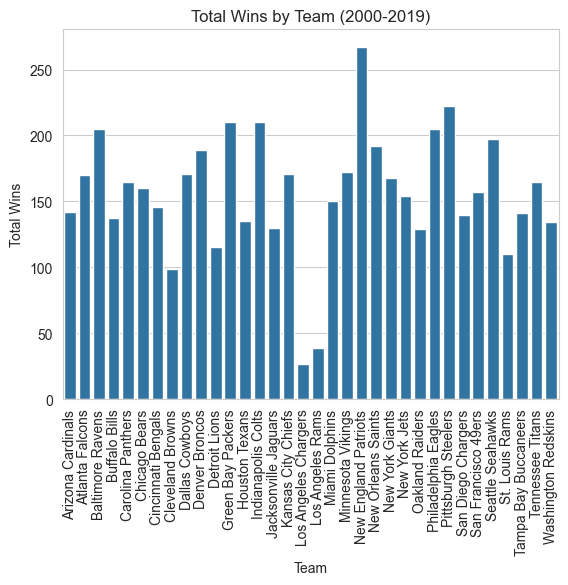

In [29]:
# Bar chart of total wins by team over the years
total_wins_by_team = avg_yards_by_team_per_year.groupby('team')['total_wins'].sum().reset_index()
sns.barplot(data=total_wins_by_team, x='team', y='total_wins')
plt.xlabel('Team')
plt.ylabel('Total Wins')
plt.title('Total Wins by Team (2000-2019)')
plt.xticks(rotation=90)
plt.show()

In [30]:
avg_yards_by_team_per_year['total_wins'] = pd.to_numeric(avg_yards_by_team_per_year['total_wins'])

In [31]:
model = smf.ols("total_wins ~ total_avg_yards", data=avg_yards_by_team_per_year).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             total_wins   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     206.9
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           8.20e-41
Time:                        12:03:27   Log-Likelihood:                -1610.2
No. Observations:                 636   AIC:                             3224.
Df Residuals:                     634   BIC:                             3233.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -6.4613      1.038     

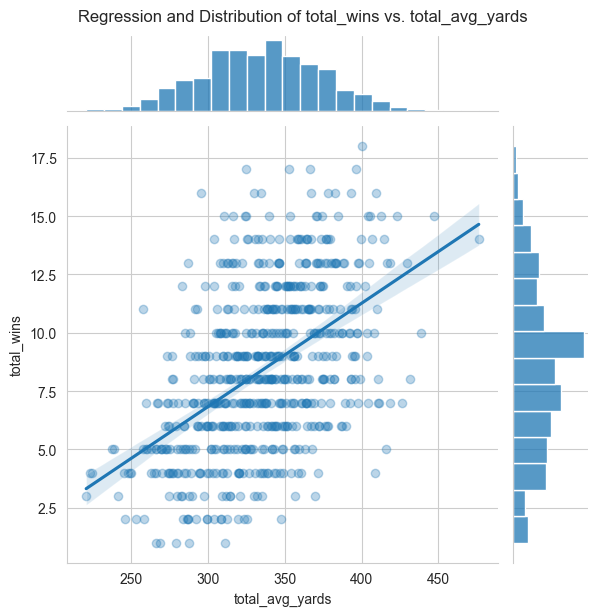

In [32]:
x_var = 'total_avg_yards'
y_var = 'total_wins'
g = sns.JointGrid(data=avg_yards_by_team_per_year, x=x_var, y=y_var)
g.plot_joint(sns.regplot, scatter_kws={'alpha': 0.3})
g.plot_marginals(sns.histplot)
g.figure.suptitle(f'Regression and Distribution of {y_var} vs. {x_var}', y=1.02)
plt.show()

In [ ]:
san_diego_mask = avg_yards_by_team_per_year['team'] == 'San Diego Chargers'
lac_mask = avg_yards_by_team_per_year['team'] == 'Los Angeles Chargers'
st_louis_mask = avg_yards_by_team_per_year['team'] == 'St. Louis Rams'
lar_mask = avg_yards_by_team_per_year['team'] == 'Los Angeles Rams'

np.int64(167)

In [36]:
# Total wins by Chargers franchise
avg_yards_by_team_per_year[san_diego_mask]['total_wins'].sum() + avg_yards_by_team_per_year[lac_mask]['total_wins'].sum()

np.int64(167)

In [35]:
# Total wins by Rams fracnhise
avg_yards_by_team_per_year[st_louis_mask]['total_wins'].sum() + avg_yards_by_team_per_year[lar_mask]['total_wins'].sum()

np.int64(149)